# ML Project - Urban Air Pollution

## Questions
- 
    
## Remarks
- data set 01/02/2020 til 04/04/2020 (Covid-19)


## TODO
- update baseline model re: y_train_transformed
- stratify train/ test split? fix bug

In [295]:
# import libraries

import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin, RegressorMixin
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
from sklearn.dummy import DummyRegressor


In [197]:
# load data set

df_raw = pd.read_csv("data/Train.csv")

In [198]:
# define feature variable and target variable

# target-related columns, use for hyperparameterization
target_cols = ['target', 'target_min', 'target_max', 'target_variance', 'target_count']

# drop target-related cols
X = df_raw.drop(target_cols, axis=1)

# use only target column
# other target_cols variables as hyperparams?
Y = df_raw['target']


In [235]:
# train-test split 
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.25, random_state=42) # stratify=Y ?

## Data Cleaning & EDA

In [210]:
# % of missing values
missing_pct = X_train.isnull().sum() * 100 / len(X_train)
print("Missing % per feature:")
print(missing_pct.sort_values(ascending=False))


Missing % per feature:
L3_CH4_solar_zenith_angle               81.17991
L3_CH4_solar_azimuth_angle              81.17991
L3_CH4_sensor_zenith_angle              81.17991
L3_CH4_sensor_azimuth_angle             81.17991
L3_CH4_aerosol_optical_depth            81.17991
                                          ...   
specific_humidity_2m_above_ground        0.00000
relative_humidity_2m_above_ground        0.00000
precipitable_water_entire_atmosphere     0.00000
Place_ID                                 0.00000
Place_ID X Date                          0.00000
Length: 77, dtype: float64


In [240]:
# df with missing values in df_raw
missing_df = pd.DataFrame({
    'missing_count': X_train.isnull().sum(),
    'missing_pct': missing_pct.round(2)
}).sort_values('missing_pct', ascending=False)

missing_df

,missing_count,missing_pct
L3_CH4_solar_zenith_angle,18604,81.18
L3_CH4_solar_azimuth_angle,18604,81.18
L3_CH4_sensor_zenith_angle,18604,81.18
L3_CH4_sensor_azimuth_angle,18604,81.18
L3_CH4_aerosol_optical_depth,18604,81.18
...,...,...
specific_humidity_2m_above_ground,0,0.00
relative_humidity_2m_above_ground,0,0.00
precipitable_water_entire_atmosphere,0,0.00
Place_ID,0,0.00


In [257]:
# fit and transform rows re missing values above threshold
# cgpt
class RowFilterByMissingness(BaseEstimator, TransformerMixin):
    def __init__(self, max_missing_fraction=0.20):
        self.max_missing_fraction = max_missing_fraction

    def fit(self, X, y=None):
        # compute row-wise missing fraction
        self.row_missing_fraction_ = X.isna().mean(axis=1)

        # rows to keep
        self.keep_mask_ = self.row_missing_fraction_ <= self.max_missing_fraction

        return self

    def transform(self, X):
        return X.loc[self.keep_mask_].copy()

    def transform_y(self, y):
        return y.loc[self.keep_mask_].copy()


In [258]:
# fit and transform columns re missing values above threshold
# cgpt
class ColumnDropper(BaseEstimator, TransformerMixin):
    def __init__(self, drop_cols=None, cat_cols=None):
        self.drop_cols = drop_cols or []
        self.cat_cols = cat_cols or []

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X.drop(self.drop_cols + self.cat_cols, axis=1, errors="ignore")


In [271]:
# preprocess pipeline using col dropper + row dropper classes

preprocess_pipeline = Pipeline(
    steps=[
        ("row_filter", RowFilterByMissingness(max_missing_fraction=0.20)),
        ("column_dropper", ColumnDropper(drop_cols=drop_cols, cat_cols=cat_cols)),
    ]
)


In [272]:
# fit on training data to yield X_train_clean
X_train_clean = preprocess_pipeline.fit_transform(X_train, y_train)

# apply identical row filtering to y
row_filter = preprocess_pipeline.named_steps["row_filter"]
y_train_clean = row_filter.transform_y(y_train)


In [273]:
# if this fails, something upstream is broken
assert X_train_clean.index.equals(y_train_clean.index)


In [269]:
# re hp tuning later
param_grid = {
    "row_filter__max_missing_fraction": [0.1, 0.2, 0.3, 0.4]
}


In [248]:
# keep as fallback re cleaning
# drop columns with missing values % > 30 - from X_train or df_raw?


#drop_cols = ['L3_CH4_CH4_column_volume_mixing_ratio_dry_air', 
#            'L3_CH4_aerosol_height', 
#            'L3_CH4_aerosol_optical_depth', 
#            'L3_CH4_sensor_azimuth_angle',
#            'L3_CH4_sensor_zenith_angle',
#            'L3_CH4_solar_azimuth_angle',
#            'L3_CH4_solar_zenith_angle']

#cat_cols = ['Place_ID X Date', 'Date', 'Place_ID']
             
# update X_train regarding missing values   
#X_train_clean = (X_train
#                 .drop(drop_cols, axis=1)
#                 .drop(cat_cols, axis=1)
#                 .copy())

#X_train_clean.head()


,precipitable_water_entire_atmosphere,relative_humidity_2m_above_ground,specific_humidity_2m_above_ground,temperature_2m_above_ground,u_component_of_wind_10m_above_ground,v_component_of_wind_10m_above_ground,L3_NO2_NO2_column_number_density,L3_NO2_NO2_slant_column_number_density,L3_NO2_absorbing_aerosol_index,L3_NO2_cloud_fraction,...,L3_AER_AI_solar_zenith_angle,L3_SO2_SO2_column_number_density,L3_SO2_SO2_column_number_density_amf,L3_SO2_SO2_slant_column_number_density,L3_SO2_absorbing_aerosol_index,L3_SO2_cloud_fraction,L3_SO2_sensor_azimuth_angle,L3_SO2_sensor_zenith_angle,L3_SO2_solar_azimuth_angle,L3_SO2_solar_zenith_angle
18386,15.500000,73.750000,0.004229,5.585741,-0.978223,-1.065103,0.000069,0.000159,-1.055219,0.757271,...,54.442826,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13906,13.200000,69.500000,0.005473,10.474451,-1.074905,-1.208772,0.000070,0.000181,-0.919397,0.136592,...,42.559485,-0.000113,0.417257,-0.000023,-1.075716,0.241470,67.428639,55.364644,-173.368951,42.559485
27896,9.108644,60.587501,0.003550,6.236047,1.440190,-0.529011,0.000232,0.000378,-1.496493,0.019698,...,57.433720,0.000144,0.393872,0.000057,-2.194424,0.018929,71.916639,26.080296,-168.388678,57.430464
3463,9.940000,57.140002,0.003854,8.377051,1.678333,-1.798787,0.000067,0.000123,-1.564904,0.130911,...,51.604267,0.000627,0.309415,0.000187,-2.039564,0.188527,-98.101253,34.882890,-156.722085,51.604267
6706,14.900001,70.300003,0.006390,10.458612,0.195703,-0.708057,0.000099,0.000227,-1.227443,0.340044,...,41.528331,0.000105,0.414429,0.000041,-1.722877,0.294336,-9.353199,59.477474,-157.914741,41.350113


In [300]:
# log transform y 

y_train_transformed = np.log1p(y_train)
y_test_transformed = np.log1p(y_test)

# convert back after model building
# y_pred_original_scale = np.expm1(y_pred_transformed)

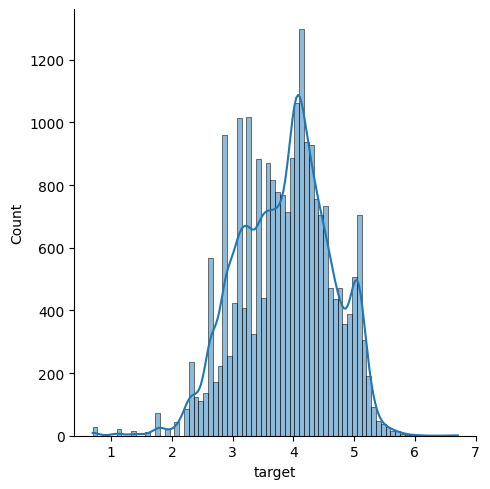

In [301]:
# y_transformed distribution
sns.displot(y_train_transformed, kde=True) 

In [249]:
# data cleaning
X_train_clean.head()

,precipitable_water_entire_atmosphere,relative_humidity_2m_above_ground,specific_humidity_2m_above_ground,temperature_2m_above_ground,u_component_of_wind_10m_above_ground,v_component_of_wind_10m_above_ground,L3_NO2_NO2_column_number_density,L3_NO2_NO2_slant_column_number_density,L3_NO2_absorbing_aerosol_index,L3_NO2_cloud_fraction,...,L3_AER_AI_solar_zenith_angle,L3_SO2_SO2_column_number_density,L3_SO2_SO2_column_number_density_amf,L3_SO2_SO2_slant_column_number_density,L3_SO2_absorbing_aerosol_index,L3_SO2_cloud_fraction,L3_SO2_sensor_azimuth_angle,L3_SO2_sensor_zenith_angle,L3_SO2_solar_azimuth_angle,L3_SO2_solar_zenith_angle
18386,15.500000,73.750000,0.004229,5.585741,-0.978223,-1.065103,0.000069,0.000159,-1.055219,0.757271,...,54.442826,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13906,13.200000,69.500000,0.005473,10.474451,-1.074905,-1.208772,0.000070,0.000181,-0.919397,0.136592,...,42.559485,-0.000113,0.417257,-0.000023,-1.075716,0.241470,67.428639,55.364644,-173.368951,42.559485
27896,9.108644,60.587501,0.003550,6.236047,1.440190,-0.529011,0.000232,0.000378,-1.496493,0.019698,...,57.433720,0.000144,0.393872,0.000057,-2.194424,0.018929,71.916639,26.080296,-168.388678,57.430464
3463,9.940000,57.140002,0.003854,8.377051,1.678333,-1.798787,0.000067,0.000123,-1.564904,0.130911,...,51.604267,0.000627,0.309415,0.000187,-2.039564,0.188527,-98.101253,34.882890,-156.722085,51.604267
6706,14.900001,70.300003,0.006390,10.458612,0.195703,-0.708057,0.000099,0.000227,-1.227443,0.340044,...,41.528331,0.000105,0.414429,0.000041,-1.722877,0.294336,-9.353199,59.477474,-157.914741,41.350113


In [250]:
X_train_clean.nunique()

precipitable_water_entire_atmosphere     9923
relative_humidity_2m_above_ground        8780
specific_humidity_2m_above_ground       16575
temperature_2m_above_ground             22301
u_component_of_wind_10m_above_ground    21594
                                        ...  
L3_SO2_cloud_fraction                   16513
L3_SO2_sensor_azimuth_angle             17262
L3_SO2_sensor_zenith_angle              17262
L3_SO2_solar_azimuth_angle              17262
L3_SO2_solar_zenith_angle               17262
Length: 67, dtype: int64

In [264]:
print(X_train_clean.info())  # non-null counts per column

<class 'pandas.core.frame.DataFrame'>
Index: 16805 entries, 13906 to 15795
Data columns (total 67 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   precipitable_water_entire_atmosphere                 16805 non-null  float64
 1   relative_humidity_2m_above_ground                    16805 non-null  float64
 2   specific_humidity_2m_above_ground                    16805 non-null  float64
 3   temperature_2m_above_ground                          16805 non-null  float64
 4   u_component_of_wind_10m_above_ground                 16805 non-null  float64
 5   v_component_of_wind_10m_above_ground                 16805 non-null  float64
 6   L3_NO2_NO2_column_number_density                     16804 non-null  float64
 7   L3_NO2_NO2_slant_column_number_density               16804 non-null  float64
 8   L3_NO2_absorbing_aerosol_index                       16804 non-null

In [253]:
# Missing counts per column
print(X_train_clean.isnull().sum()) 


precipitable_water_entire_atmosphere       0
relative_humidity_2m_above_ground          0
specific_humidity_2m_above_ground          0
temperature_2m_above_ground                0
u_component_of_wind_10m_above_ground       0
                                        ... 
L3_SO2_cloud_fraction                   5407
L3_SO2_sensor_azimuth_angle             5407
L3_SO2_sensor_zenith_angle              5407
L3_SO2_solar_azimuth_angle              5407
L3_SO2_solar_zenith_angle               5407
Length: 67, dtype: int64


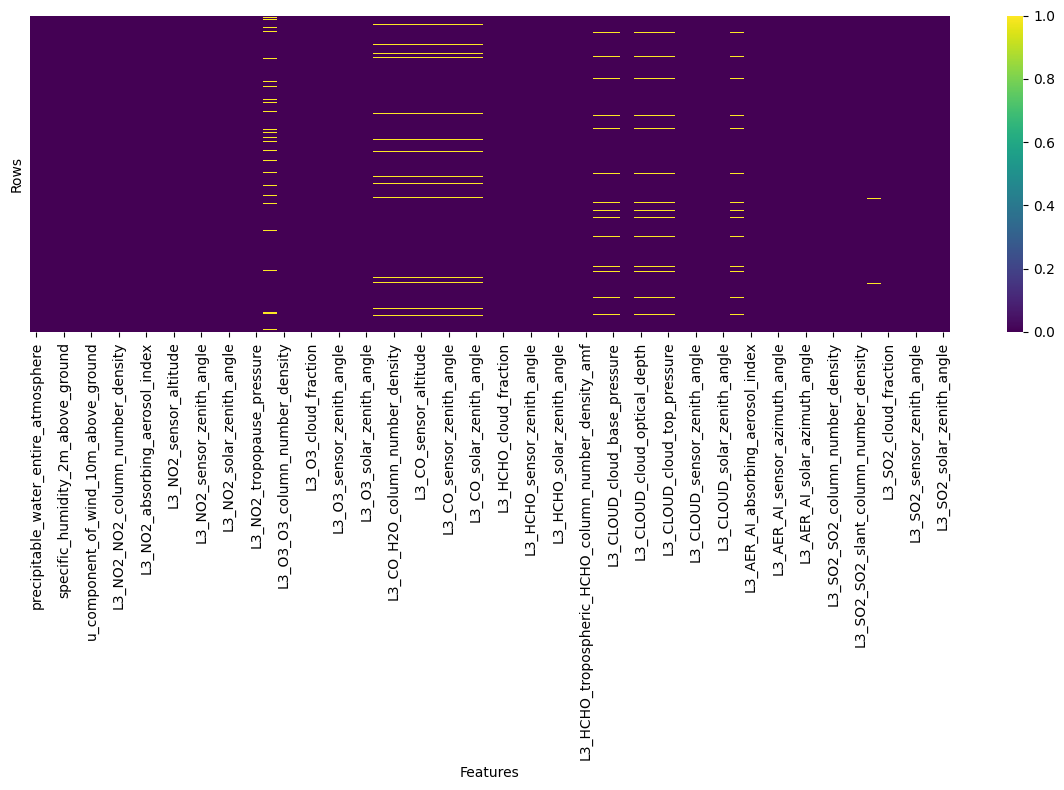

In [274]:
# heatmap of missing values

# Missing values matrix (0=complete, 1=missing)
missing_matrix = X_train_clean.isnull()

plt.figure(figsize=(12, 8))
sns.heatmap(missing_matrix, 
            #cbar=True, 
            yticklabels=False, 
            cmap='viridis')
#plt.title('Missing Values Heatmap - X_train')
plt.xlabel('Features')
plt.ylabel('Rows')
plt.tight_layout()
plt.show()


In [296]:
# create baseline model, default strategy: mean
baseline_model = DummyRegressor(strategy='mean')
baseline_model.fit(X_train_clean, y_train_clean)

DummyRegressor()

In [293]:
# 
y_pred_baseline = baseline_model.predict(y_test)

In [294]:
baseline_rmse = round(np.sqrt(mean_squared_error(y_test,y_pred_baseline)),6)
baseline_rmse

46.469336

In [290]:
y.median()

50.0

In [ ]:

class BaselineRegressor(BaseEstimator, RegressorMixin):
    """
    Baseline regressor that always predicts the mean of y
    """
    def __init__(self, strategy="mean"):
        self.strategy = strategy

    def fit(self, X, y):
        

        if self.strategy == "median":
            self.y_pred = y.median()
        elif self.strategy == "mean":
            self.y_pred = y.mean()
        else:
            raise ValueError("strategy must be 'mean' or 'median'")

        return self

    def predict(self, X):
        return np.array(X.shape[0]*[self.y_pred])
